In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
#TensorFlow Hub is a repository of trained machine learning models.

In [ ]:
#creating a dataframe of the csv file using pandas
#usecols is used to specify the columns from thhe dataset which we r gonna use
df=pd.read_csv("wine-reviews.csv",usecols=['country','description','designation','points','price','variety','winery'])

In [ ]:
#we want to focus on the two terms description and points so use:-
df=df.dropna(subset=["description","points"])

In [ ]:
df.head()

,country,description,designation,points,price,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Pinot Noir,Sweet Cheeks


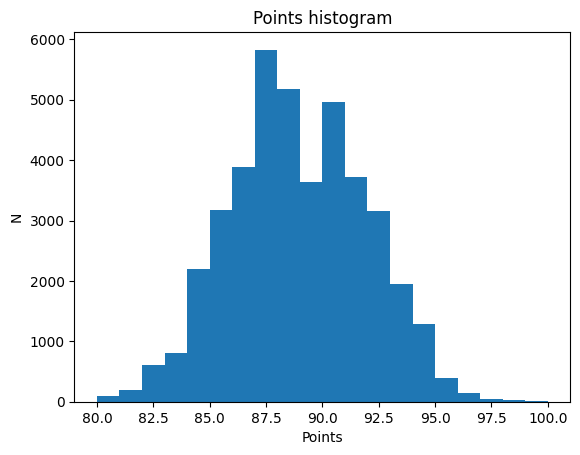

In [ ]:
#now we r gonna plot the points to see the distribution of the points using matplotlib
plt.hist(df.points,bins=20)
#shows the distribution of values using a histogram
plt.title("Points histogram")
plt.ylabel("N")
plt.xlabel("Points")
plt.show()

In [ ]:
df["label"]=(df.points>=90).astype(int)
df=df[["description","label"]]

In [ ]:
df.head()

,description,label
0,"Aromas include tropical fruit, broom, brimston...",0
1,"This is ripe and fruity, a wine that is smooth...",0
2,"Tart and snappy, the flavors of lime flesh and...",0
3,"Pineapple rind, lemon pith and orange blossom ...",0
4,"Much like the regular bottling from 2012, this...",0


In [ ]:
df.tail()

,description,label
41260,"Just beautiful, a dry, silky Pinot Noir, fille...",1
41261,"Exotic aromas of fig pudding, prune and cocoa ...",1
41262,"This is a full-bodied, muscular example of Côt...",1
41263,T-L's 2007s from the Northern Rhône came out w...,1
41264,"Here's an easy, soft Pinot, a real crowd pleas...",1


In [ ]:
train,val,test=np.split(df.sample(frac=1),[int(0.8*len(df)),int(0.9*len(df))])
#split data-->  80%:training data,  10%:test data,  10%:validation data

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
len(train),  len(val),  len(test)

(33012, 4126, 4127)

In [ ]:
#create a utility function that converts each training, validation, and test set DataFrame into a tf.data.Dataset, then shuffles and batches the data.
def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
  df = dataframe.copy()
  labels = df.pop('label')
  df = df["description"]
  ds = tf.data.Dataset.from_tensor_slices((df, labels))
  if shuffle:
    ds = ds.shuffle(buffer_size=len(dataframe))
  ds = ds.batch(batch_size)
  ds = ds.prefetch(tf.data.AUTOTUNE)
  return ds

In [ ]:
train_data=df_to_dataset(train)
valid_data=df_to_dataset(val)
test_data=df_to_dataset(test)

In [ ]:
list(train_data)[0]

(<tf.Tensor: shape=(1024,), dtype=string, numpy=
 array([b"Exceptionally ripe fruit flavors of blackberry and cherry jam are brightened with crisp acidity in this dry, exotically spicy Pinot Noir. It's fine and silky in the mouth, with a brace of tannins. Drink over the next few years.",
        b'Edgy, nervy and funky, with unfamiliar aromas and flavors. The nose is pickled and the palate is tart, linear and green. Loses itself as it opens, turning more herbal, sweaty and strange. Imported by Ecovalley Quality Wine Group and National Refrescos Import Company, LLC.',
        b'A structured wine with tannins from wood aging, as well as rich blackberry fruit. The wine has fruit and structural intensity, layering spice and juiciness atop a dry core. Keep for 3\xe2\x80\x935 years.',
        ...,
        b'Showing the structure of Gevrey-Chambertin and the ripe fruit of the 2009 vintage, this bottling is immediately opulent and seductive. With its red plum flavor and balanced tannins and ac

#Embedding +  Model

In [ ]:
#embeddding used so that com. can understand text
#nnlm-en-dim50 we are gonna use this embedding(token based text embedding trained on english google news 7B corpus)
embedding="https://tfhub.dev/google/nnlm-en-dim50/2"
hub_layer=hub.KerasLayer(embedding,dtype=tf.string,trainable=True)
#transformed our text into a vector of no.s

In [ ]:
hub_layer(list(train_data)[0][0])

<tf.Tensor: shape=(1024, 50), dtype=float32, numpy=
array([[ 0.21569593, -0.04978059, -0.07340937, ..., -0.01443096,
        -0.22884013,  0.07584027],
       [ 0.4622187 , -0.27172372, -0.28759205, ...,  0.03858653,
         0.03071106,  0.04542627],
       [ 0.31363434, -0.14754996, -0.15208763, ..., -0.03282964,
         0.04816056, -0.09565137],
       ...,
       [ 0.36737722, -0.09993671,  0.0257267 , ...,  0.10796265,
        -0.1538371 ,  0.04760846],
       [ 0.03515349, -0.24803618, -0.08171323, ..., -0.22183932,
        -0.10998753, -0.17442389],
       [ 0.49944335, -0.299823  ,  0.13082676, ...,  0.18941425,
        -0.18612213, -0.01930128]], dtype=float32)>

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

# ... (rest of your code) ...

model = tf.keras.Sequential()
# Wrap the hub_layer with a Lambda layer to make it compatible with Sequential
model.add(tf.keras.layers.Lambda(lambda x: hub_layer(x)))
model.add(tf.keras.layers.Dense(16, activation='relu'))
#to fix over training of the model use dropout
#as our model is workin well without using dropout so no need to use it
model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(16,activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))



"""
model=tf.keras.Sequential()
model.add(hub_layer)
model.add(tf.keras.layers.Dense(16,activation='relu'))
#to fix over training of the model use dropout
#as our model is workin well without using dropout so no need to use it
#model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(16,activation='relu'))
#model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))
"""

"\nmodel=tf.keras.Sequential()\nmodel.add(hub_layer)\nmodel.add(tf.keras.layers.Dense(16,activation='relu'))\n#to fix over training of the model use dropout\n#as our model is workin well without using dropout so no need to use it\n#model.add(tf.keras.layers.Dropout(0.4))\nmodel.add(tf.keras.layers.Dense(16,activation='relu'))\n#model.add(tf.keras.layers.Dropout(0.4))\nmodel.add(tf.keras.layers.Dense(1,activation='sigmoid'))\n"

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

In [ ]:
model.evaluate(train_data)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4073 - loss: 0.7014


[0.7013911008834839, 0.40891191363334656]

In [ ]:
model.evaluate(valid_data)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4061 - loss: 0.7028


[0.7027013301849365, 0.405962198972702]

In [ ]:
history=model.fit(train_data,epochs=10,validation_data=valid_data)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5327 - loss: 0.6941 - val_accuracy: 0.6207 - val_loss: 0.6682
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6149 - loss: 0.6712 - val_accuracy: 0.6214 - val_loss: 0.6630
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6201 - loss: 0.6660 - val_accuracy: 0.6222 - val_loss: 0.6556
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6224 - loss: 0.6594 - val_accuracy: 0.6277 - val_loss: 0.6485
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6277 - loss: 0.6534 - val_accuracy: 0.6372 - val_loss: 0.6397
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6397 - loss: 0.6446 - val_accuracy: 0.6621 - val_loss: 0.6293
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6471 - loss: 0.6364 - val_accuracy: 0.6697 - val_loss: 0.6196
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6539 - loss: 0.6277 - val_accuracy: 0.6762 - v

In [ ]:
#validation accuracy increases as we trained the model but decreases slightly at the end
#validation loss decreases and then increases at the end
#over trained

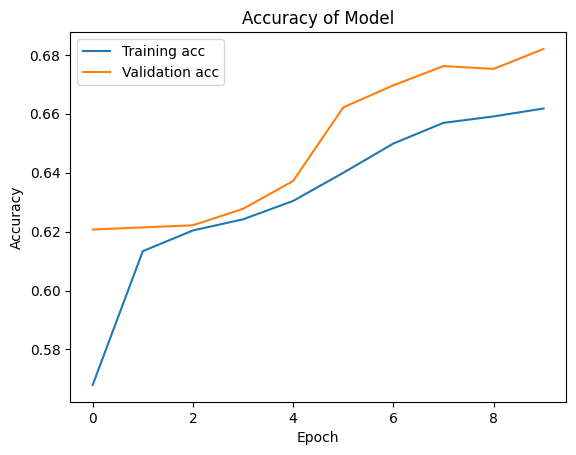

In [ ]:
plt.plot(history.history['accuracy'],label="Training acc")
plt.plot(history.history['val_accuracy'],label="Validation acc")
plt.title("Accuracy of Model")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

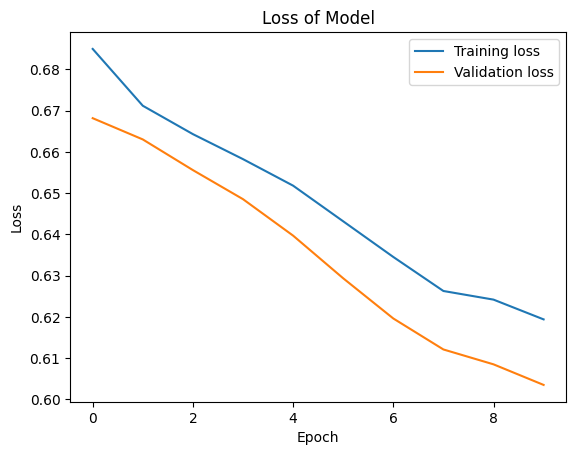

In [ ]:
plt.plot(history.history['loss'],label="Training loss")
plt.plot(history.history['val_loss'],label="Validation loss")
plt.title("Loss of Model")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [ ]:
model.evaluate(test_data)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6733 - loss: 0.6065


[0.6003766059875488, 0.6818512082099915]

#LSTM

In [ ]:
encoder=tf.keras.layers.TextVectorization(max_tokens=2000)
encoder.adapt(train_data.map(lambda text, label:text))

In [ ]:
vocab=np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'and', 'the', 'a', 'of', 'with', 'this', 'is', 'wine',
       'flavors', 'in', 'to', 'it', 'its', 'fruit', 'on', 'aromas',
       'palate', 'that'], dtype='<U17')

In [ ]:
model=tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=32,
        mask_zero=True
    ),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1,activation='sigmoid'),
])

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

In [ ]:
model.evaluate(train_data)
model.evaluate(valid_data)

75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.4233 - loss: 0.6938
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.4351 - loss: 0.6938


[0.6938446760177612, 0.4249895215034485]

In [ ]:
history=model.fit(train_data,epochs=5,validation_data=valid_data)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 425ms/step - accuracy: 0.6338 - loss: 0.6432 - val_accuracy: 0.8195 - val_loss: 0.3957
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 420ms/step - accuracy: 0.8213 - loss: 0.3950 - val_accuracy: 0.8381 - val_loss: 0.3594
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 419ms/step - accuracy: 0.8392 - loss: 0.3594 - val_accuracy: 0.8430 - val_loss: 0.3476
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 437ms/step - accuracy: 0.8462 - loss: 0.3468 - val_accuracy: 0.8430 - val_loss: 0.3455
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 433ms/step - accuracy: 0.8476 - loss: 0.3452 - val_accuracy: 0.8423 - val_loss: 0.3494


In [ ]:
model.evaluate(test_data)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.8433 - loss: 0.3566


[0.3515073359012604, 0.8445237278938293]